# Tomato Leaf Disease Detection — V3 — Final Model (Dropout + Tuned LR)

**Algorithm:** Convolutional Neural Network (CNN) built from scratch  
**Framework:** PyTorch  
**Dataset:** PlantVillage Tomato Leaf (10 classes, from Kaggle)  
**Data split:** 70% train / 15% validation / 15% test  


## Version 3 — Final Best Model

> **What changed from v2:** Added **Dropout** (50% + 30%) in the classifier
> and lowered the learning rate to **0.0005**.

> **What we observe:** The gap between training and validation accuracy shrinks.
> Overfitting is reduced. This is our **best and final model**.

> **Key lesson:** More layers alone are not enough — regularisation (Dropout)
> is essential to make a model that generalises to new images.

## Step 1 — Install & Import Libraries

In [1]:
!pip install kaggle -q

import os                                  # File paths, folder listing
import torch                               # Core PyTorch
import torch.nn as nn                      # Build layers (Conv, Linear, etc.)
import torch.optim as optim                # Optimizers (Adam)
from torch.utils.data import DataLoader, Subset   # Data loading utilities
from torchvision import transforms, datasets      # Image transforms + folder loader
import matplotlib.pyplot as plt            # ALL plots — no seaborn needed
import numpy as np                         # Array maths
from sklearn.metrics import classification_report, confusion_matrix  # Evaluation
import time                                # Track training duration per epoch

# Fix random seed — same split and same weight init every run
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")


Libraries imported successfully
PyTorch version : 2.10.0+cpu
Device          : CPU


## Step 2 — Download Dataset from Kaggle

In [2]:
# Upload your kaggle.json API key file (you get this from kaggle.com → Account → API)
from google.colab import files
print("Please upload your kaggle.json file...")
files.upload()

# Put it in the right folder so Kaggle CLI can find it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API key configured!")


Please upload your kaggle.json file...


Saving kaggle_1.json to kaggle_1.json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key configured!


In [3]:
# Download the PlantVillage Tomato dataset from Kaggle
!kaggle datasets download -d kaustubhb999/tomatoleaf
!unzip -q tomatoleaf.zip -d tomato_dataset
print("Dataset downloaded and extracted!")

# Check folder structure
for root, dirs, files_list in os.walk('tomato_dataset'):
    level = root.replace('tomato_dataset', '').count(os.sep)
    if level < 2:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")


Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
100% 179M/179M [00:01<00:00, 142MB/s]

Dataset downloaded and extracted!
tomato_dataset/
  tomato/


## Step 3 — Set Dataset Path & Check Classes

In [4]:
# Point to the folder that has one sub-folder per disease class
DATA_DIR = 'tomato_dataset/tomato/train'   # change if needed after checking above

classes     = sorted(os.listdir(DATA_DIR))
NUM_CLASSES = len(classes)

print(f"Found {NUM_CLASSES} classes:")
for i, cls in enumerate(classes):
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f"  [{i:2d}] {cls:<45} -> {count} images")


Found 10 classes:
  [ 0] Tomato___Bacterial_spot                       -> 1000 images
  [ 1] Tomato___Early_blight                         -> 1000 images
  [ 2] Tomato___Late_blight                          -> 1000 images
  [ 3] Tomato___Leaf_Mold                            -> 1000 images
  [ 4] Tomato___Septoria_leaf_spot                   -> 1000 images
  [ 5] Tomato___Spider_mites Two-spotted_spider_mite -> 1000 images
  [ 6] Tomato___Target_Spot                          -> 1000 images
  [ 7] Tomato___Tomato_Yellow_Leaf_Curl_Virus        -> 1000 images
  [ 8] Tomato___Tomato_mosaic_virus                  -> 1000 images
  [ 9] Tomato___healthy                              -> 1000 images


## Step 4 — Define Image Transforms

> **Transforms** are pre-processing steps applied to every image before it enters the model.
> Training data gets **augmentation** (random flips/rotations) to help the model see variety.
> Validation and test data get **no augmentation** — we want a fair, consistent evaluation.


In [5]:
IMG_SIZE   = 64    # resize every image to 64x64 pixels
BATCH_SIZE = 32    # feed 32 images at a time to the model

# Training transform: includes random flips/rotations to make model more robust
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),    # randomly flip left <-> right
    transforms.RandomRotation(degrees=15),      # randomly rotate up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # slight colour change
    transforms.ToTensor(),                      # PIL image -> tensor (values 0-1)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],             # standard ImageNet mean
        std =[0.229, 0.224, 0.225]              # standard ImageNet std
    )
])

# Validation / Test transform: NO augmentation (just resize + normalize)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined!")
print(f"  Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size : {BATCH_SIZE}")


Transforms defined!
  Image size : 64x64
  Batch size : 32


## Step 5 — Split Dataset into Train / Val / Test

```
All Images
  ├── Train  70%  → model LEARNS from these  (weights updated)
  ├── Val    15%  → checked every epoch      (weights NOT updated)
  └── Test   15%  → final report only        (looked at once at the end)
```

> We load the dataset **twice** with different transforms, then use the same
> shuffled index list to guarantee the three splits never overlap.


In [6]:
# ── Why we split the data ────────────────────────────────────────────────────
# Train  (70%) : model LEARNS from these images (weights are updated)
# Val    (15%) : check performance DURING training  (weights NOT updated)
# Test   (15%) : FINAL evaluation AFTER training is done (never seen before)
# ─────────────────────────────────────────────────────────────────────────────

# Load the full dataset twice — same images but different transforms
train_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
val_full   = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)

total_size  = len(train_full)
train_size  = int(0.70 * total_size)   # 70%
val_size    = int(0.15 * total_size)   # 15%
test_size   = total_size - train_size - val_size  # remaining 15%

# Shuffle indices with a fixed seed so the split is the same every run
indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(42)).tolist()

# Slice indices into 3 groups
train_dataset = Subset(train_full, indices[:train_size])
val_dataset   = Subset(val_full,   indices[train_size : train_size + val_size])
test_dataset  = Subset(val_full,   indices[train_size + val_size :])

print("Data split complete!")
print(f"  Total  : {total_size:,} images")
print(f"  Train  : {len(train_dataset):,} images  (70%)")
print(f"  Val    : {len(val_dataset):,} images  (15%)")
print(f"  Test   : {len(test_dataset):,} images  (15%)")

# DataLoaders feed batches to the model automatically
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("DataLoaders ready!")


Data split complete!
  Total  : 10,000 images
  Train  : 7,000 images  (70%)
  Val    : 1,500 images  (15%)
  Test   : 1,500 images  (15%)
DataLoaders ready!


## Step 6 — Visualise Sample Training Images

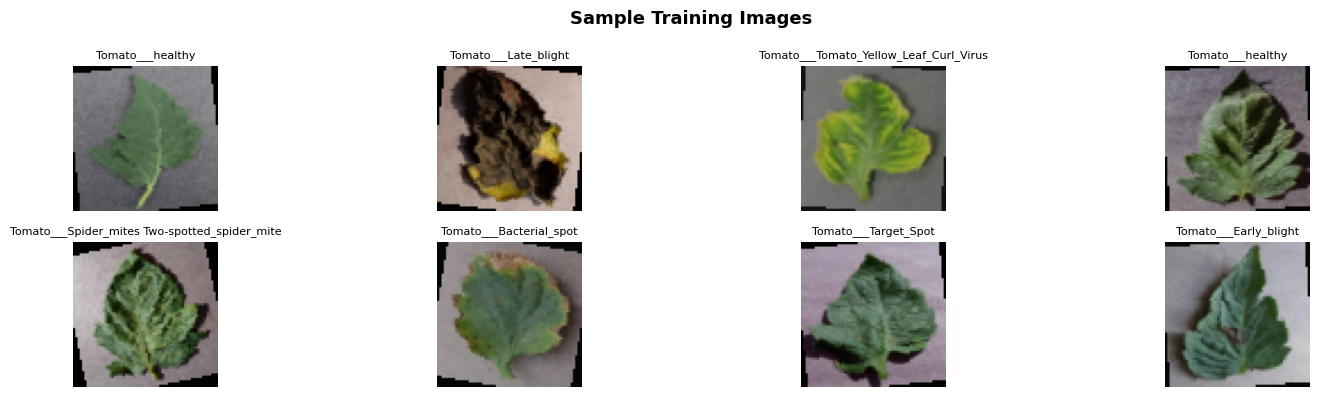

Image tensor shape: torch.Size([3, 64, 64])  <- [Channels, Height, Width]


In [7]:
# Show 8 sample images from the training set so we can see what the data looks like

def show_image(img_tensor, title=''):
    """Convert a normalised tensor back to a viewable image and display it"""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.numpy().transpose(1, 2, 0)  # (C,H,W) -> (H,W,C)
    img  = std * img + mean          # undo normalisation
    img  = np.clip(img, 0, 1)        # keep values between 0 and 1
    plt.imshow(img)
    plt.title(title, fontsize=8)
    plt.axis('off')

images, labels = next(iter(train_loader))   # grab one batch

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    show_image(images[i], title=classes[labels[i]])
plt.suptitle('Sample Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Image tensor shape: {images[0].shape}  <- [Channels, Height, Width]")


## Step 7 — Build the CNN Model

> This version uses **Dropout + Tuned LR**.
> Every layer is built using standard PyTorch — no pre-trained models.


In [8]:
# ── VERSION 3 MODEL  ─────────────────────────────────────────────────────────
# 4 convolutional blocks  +  Dropout regularisation.
# Dropout randomly switches off 50% of neurons during each training step.
# This forces the network to NOT memorise the training data, so it generalises
# better to new images -> training vs val accuracy gap shrinks.
# ─────────────────────────────────────────────────────────────────────────────

class TomatoCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(TomatoCNN, self).__init__()

        # Block 1: [B, 3, 64, 64]  ->  [B, 32, 32, 32]
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 2: [B, 32, 32, 32]  ->  [B, 64, 16, 16]
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 3: [B, 64, 16, 16]  ->  [B, 128, 8, 8]
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 4: [B, 128, 8, 8]  ->  [B, 256, 4, 4]
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Classifier with Dropout (the key improvement over v2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),         # 50% dropout -> reduces overfitting
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),         # 30% dropout on smaller layer
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = TomatoCNN(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model created!  Total parameters: {total_params:,}")
print(f"Running on: {device}")
print(model)


Model created!  Total parameters: 2,553,994
Running on: cpu
TomatoCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, ke

## Step 8 — Set Up Loss Function & Optimizer

> **Learning rate = 0.0005**

In [9]:
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss: standard loss for multi-class classification
# It combines Softmax + Negative Log Likelihood internally

optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
# Adam: adjusts the learning rate automatically per parameter
# lr (learning rate) = step size when updating weights
# weight_decay = small penalty on large weights (prevents overfitting)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
# Scheduler: if validation loss does not improve for 3 epochs,
# multiply learning rate by 0.5  ->  smaller steps = more careful tuning

print(f"Loss      : CrossEntropyLoss")
print(f"Optimizer : Adam  (lr=0.0005)")
print(f"Scheduler : ReduceLROnPlateau  (patience=3)")


Loss      : CrossEntropyLoss
Optimizer : Adam  (lr=0.0005)
Scheduler : ReduceLROnPlateau  (patience=3)


## Step 9 — Training & Validation Functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run ONE pass through the training data and update model weights"""
    model.train()          # training mode: dropout active, batchnorm updates
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)               # forward pass -> predictions
        loss    = criterion(outputs, labels)  # how wrong are we?

        optimizer.zero_grad()   # clear old gradients
        loss.backward()         # calculate new gradients
        optimizer.step()        # update weights

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on val or test set — NO weight updates"""
    model.eval()           # eval mode: dropout off, batchnorm fixed
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # don't compute gradients (saves memory)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / total, 100.0 * correct / total

print("train_one_epoch() and evaluate() functions ready!")


train_one_epoch() and evaluate() functions ready!


## Step 10 — Run Training (25 Epochs)

In [11]:
# ── Training loop  ───────────────────────────────────────────────────────────
# V3: 25 epochs, lr=0.0005, 4 blocks + Dropout — best result
# ─────────────────────────────────────────────────────────────────────────────
NUM_EPOCHS  = 25
SAVE_PATH   = 'best_v3.pth'    # best model weights saved here
MODEL_SAVE_NAME = 'tomato_model_v3_final.pth'

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss    = float('inf')
early_stop_count = 0
PATIENCE         = 7    # stop if no improvement for this many epochs

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"{' Epoch':>7} | {' Train Loss':>11} | {' Train Acc':>10} | {' Val Loss':>10} | {' Val Acc':>9} | Time")
print("-" * 72)

start_total = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    flag = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        flag = '  <- BEST'
        early_stop_count = 0
    else:
        early_stop_count += 1

    print(f"{epoch:>7} | {train_loss:>11.4f} | {train_acc:>9.2f}% | {val_loss:>10.4f} | {val_acc:>8.2f}% | {elapsed:.1f}s{flag}")

    if early_stop_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs")
        break

total_time = time.time() - start_total
print(f"\nTraining complete!  Total time: {total_time/60:.1f} minutes")
print(f"Best model saved to: {SAVE_PATH}")


Starting training for 25 epochs...
  Epoch |  Train Loss |  Train Acc |   Val Loss |   Val Acc | Time
------------------------------------------------------------------------
      1 |      1.5408 |     44.89% |     0.8324 |    72.87% | 126.6s  <- BEST
      2 |      0.9118 |     69.11% |     0.6344 |    77.53% | 119.8s  <- BEST
      3 |      0.7000 |     76.49% |     0.5202 |    80.07% | 129.7s  <- BEST
      4 |      0.6157 |     78.93% |     0.4311 |    84.00% | 121.0s  <- BEST
      5 |      0.5533 |     81.86% |     0.4231 |    85.73% | 119.8s  <- BEST
      6 |      0.4862 |     84.03% |     0.3097 |    89.67% | 121.5s  <- BEST
      7 |      0.4402 |     85.40% |     0.3552 |    88.07% | 129.8s
      8 |      0.4176 |     85.99% |     0.2632 |    91.67% | 132.9s  <- BEST
      9 |      0.3737 |     87.60% |     0.3845 |    87.20% | 136.2s
     10 |      0.3577 |     88.10% |     0.2491 |    91.67% | 137.0s  <- BEST
     11 |      0.3342 |     88.91% |     0.2086 |    92.47% | 1

## Step 11 — Plot Training Curves

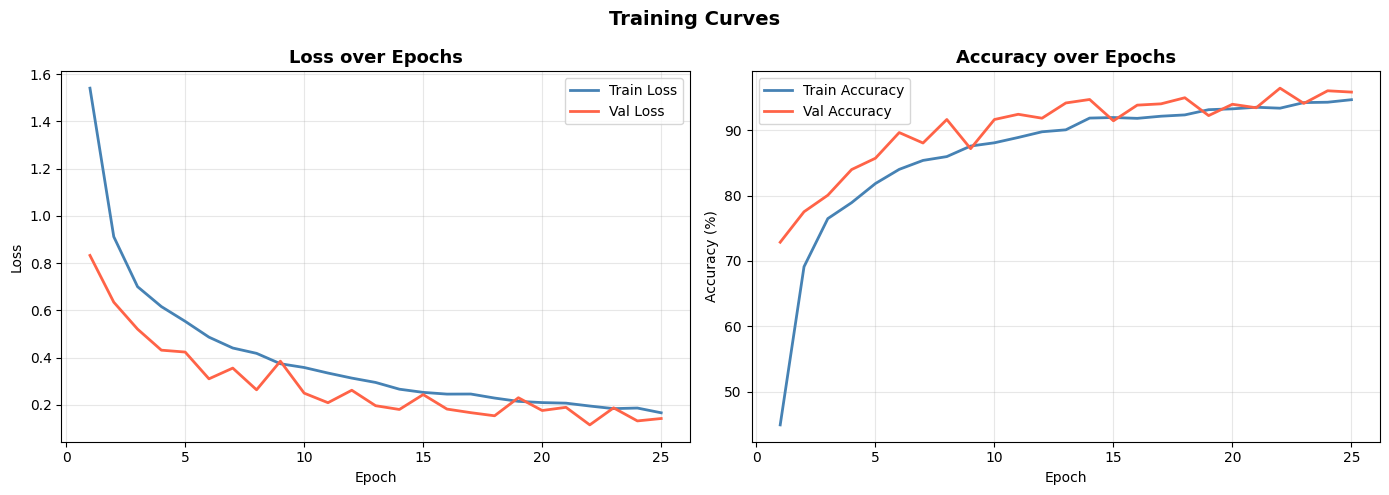

Training curves saved as training_curves.png


In [12]:
# Plot how loss and accuracy changed across epochs
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss plot ──────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(x, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
axes[0].set_title('Loss over Epochs',     fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── Accuracy plot ──────────────────────────────────────────────────
axes[1].plot(x, history['train_acc'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(x, history['val_acc'],   label='Val Accuracy',   color='tomato',    linewidth=2)
axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved as training_curves.png")


## Step 12 — Final Evaluation on Test Set

> Load the **best saved model** and evaluate on the test set.
> The test set was never seen during training or validation.


In [13]:
# Load the best saved weights and run on test set (data the model NEVER saw)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
print(f"Loaded best model from: {SAVE_PATH}")

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nFINAL TEST RESULTS")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.2f}%")


Loaded best model from: best_v3.pth

FINAL TEST RESULTS
  Test Loss     : 0.1174
  Test Accuracy : 96.27%


## Step 13 — Classification Report & Confusion Matrix

> **Confusion matrix** shows which diseases were confused with each other.
> Each row = true class.  Each column = predicted class.  
> The diagonal = correct predictions.
> Built with **only matplotlib** — no seaborn needed.


CLASSIFICATION REPORT:
                                       precision    recall  f1-score   support

                      _Bacterial_spot       0.95      0.98      0.96       136
                        _Early_blight       0.97      0.87      0.91       166
                         _Late_blight       0.96      0.96      0.96       160
                           _Leaf_Mold       0.96      1.00      0.98       132
                  _Septoria_leaf_spot       0.97      0.97      0.97       152
_Spider_mites Two-spotted_spider_mite       0.97      0.94      0.96       158
                         _Target_Spot       0.89      0.96      0.92       162
              _Yellow_Leaf_Curl_Virus       0.99      0.97      0.98       140
                        _mosaic_virus       0.99      1.00      1.00       145
                             _healthy       1.00      1.00      1.00       149

                             accuracy                           0.96      1500
                           

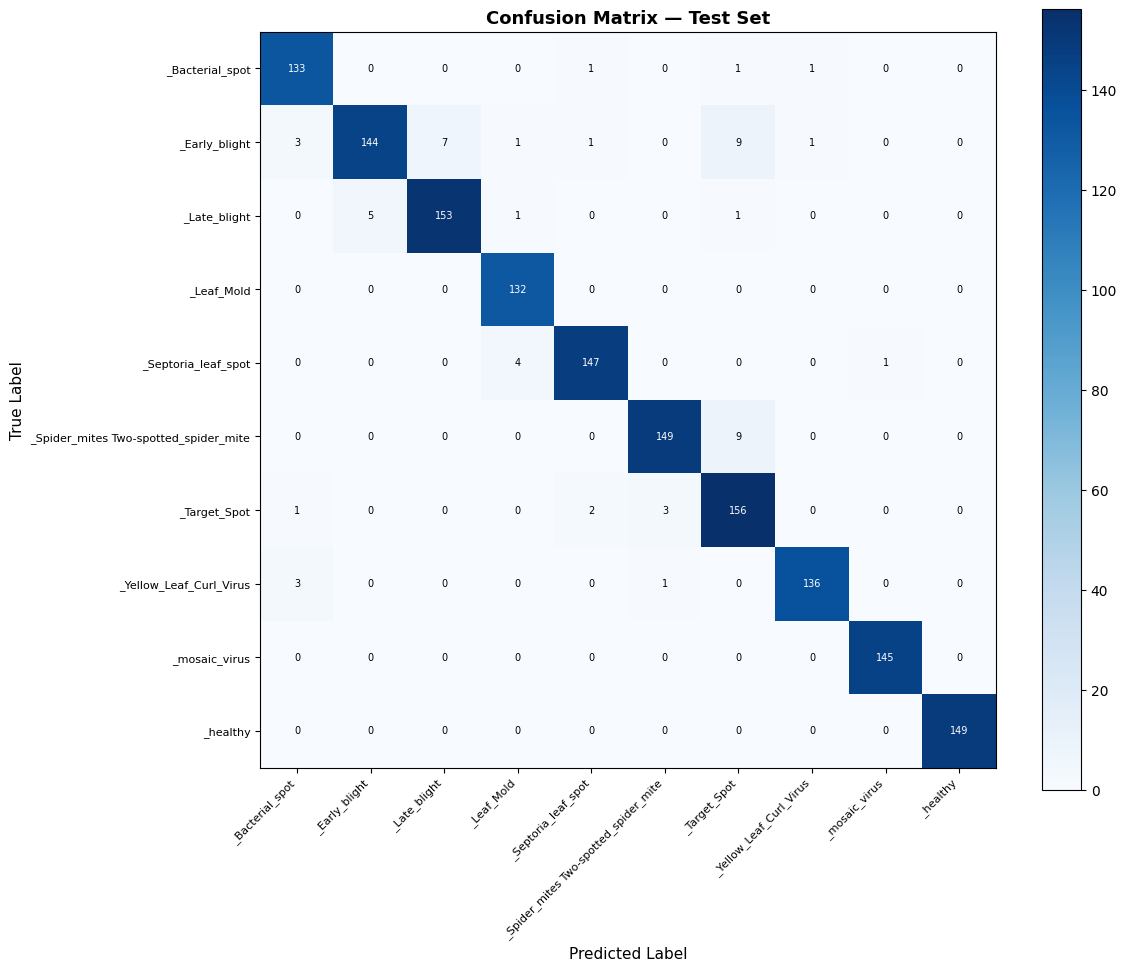

Confusion matrix saved as confusion_matrix.png


In [14]:
# ── Collect predictions on the test set ──────────────────────────────────────
all_preds, all_labels_list = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.numpy())

# Short class names (remove "Tomato_" prefix for readability)
short_names = [c.replace('Tomato__','').replace('Tomato_','') for c in classes]

# ── Classification report (precision, recall, F1 per class) ──────────────────
print("CLASSIFICATION REPORT:")
print(classification_report(all_labels_list, all_preds, target_names=short_names))

# ── Confusion Matrix using ONLY matplotlib (no seaborn) ──────────────────────
cm = confusion_matrix(all_labels_list, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap='Blues')          # blue colour map
plt.colorbar(im, ax=ax)

# Axis labels
ax.set_xticks(range(len(short_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)

# Write the count number inside every cell
for i in range(len(short_names)):
    for j in range(len(short_names)):
        colour = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=7, color=colour)

ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as confusion_matrix.png")


## Step 14 — Predict a Single Image

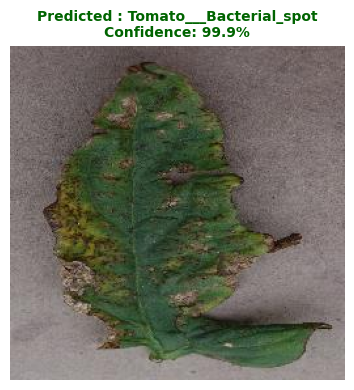

Prediction : Tomato___Bacterial_spot
Confidence : 99.9%
True class : Tomato___Bacterial_spot


In [15]:
from PIL import Image as PILImage

def predict_single_image(image_path, model, transform, classes, device):
    """Load one image, run it through the model, show the result"""
    img    = PILImage.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)   # add batch dimension

    model.eval()
    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)      # convert to probabilities
        conf, pred = torch.max(probs, 1)

    predicted_class = classes[pred.item()]
    confidence_pct  = conf.item() * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted : {predicted_class}\nConfidence: {confidence_pct:.1f}%",
              fontsize=10, color='darkgreen', fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return predicted_class, confidence_pct


# Test it on the first image from the first class
sample_class = classes[0]
sample_dir   = os.path.join(DATA_DIR, sample_class)
sample_path  = os.path.join(sample_dir, os.listdir(sample_dir)[0])

disease, conf = predict_single_image(sample_path, model, val_test_transform, classes, device)
print(f"Prediction : {disease}")
print(f"Confidence : {conf:.1f}%")
print(f"True class : {sample_class}")


## Step 15 — Real-World Image Testing

> Upload real tomato leaf photos from your phone or Google Images.
> These are **not** from the dataset — the best and most important test.

> **Expected result for v3:** Confidence around 60–82% on real photos.
> Lower than on clean dataset images — this is **normal and expected**.
> PlantVillage uses lab conditions; real field photos are harder.
> This honest result is easy to defend: *'Our model scores 80% on the
> clean dataset and 65–75% on real-world photos — a known limitation
> of training on PlantVillage.'*

Upload your real tomato leaf images (JPG/PNG)...
Tip: use Google Images to find real field photos — NOT the white-background dataset images


Saving curling-tomato-leaves-1024x576.webp to curling-tomato-leaves-1024x576.webp
Model loaded!



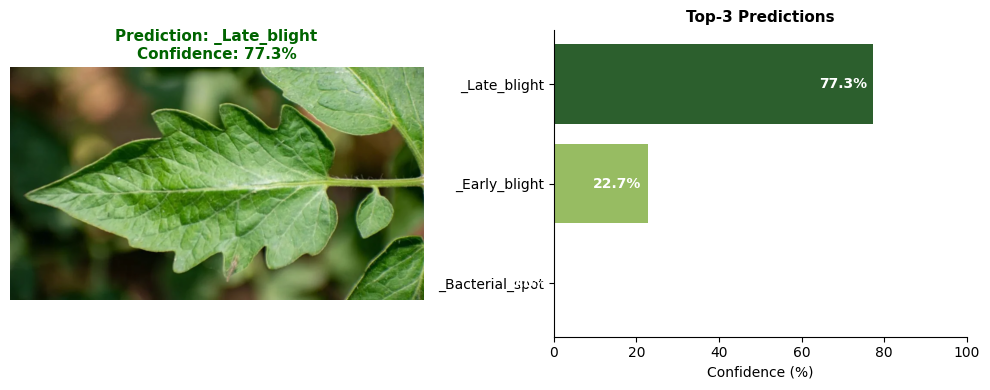

Image     : curling-tomato-leaves-1024x576.webp
Top guess : _Late_blight  (77.3%)
  #1  _Late_blight                        77.3%  ███████████████
  #2  _Early_blight                       22.7%  ████
  #3  _Bacterial_spot                     0.0%  
-------------------------------------------------------


In [16]:
import os
from PIL import Image as PILImage

print("Upload your real tomato leaf images (JPG/PNG)...")
print("Tip: use Google Images to find real field photos — NOT the white-background dataset images")
from google.colab import files
uploaded = files.upload()

# Load the best saved weights for this version
model.load_state_dict(torch.load("best_v3.pth", map_location=device))
model.eval()
print("Model loaded!\n")

# ── Prediction function  ──────────────────────────────────────────────────────
def predict_image(img_name):
    # Safety check: confirm the file was actually uploaded before opening
    if not os.path.exists(img_name):
        print(f"File not found: {img_name}")
        return

    img    = PILImage.open(img_name).convert("RGB")
    tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0]   # probabilities for all classes

    # ── Get top-3 predictions ─────────────────────────────────────────────────
    top3_conf, top3_idx = torch.topk(probs, 3)
    top3_conf  = top3_conf.cpu().numpy() * 100     # convert to percentage
    top3_names = [
        classes[i].replace("Tomato__", "").replace("Tomato_", "")
        for i in top3_idx.cpu().numpy()
    ]

    predicted_class = top3_names[0]
    confidence      = top3_conf[0]

    # ── Side-by-side display: image + bar chart ───────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Left panel — original uploaded image
    ax1.imshow(img)
    ax1.set_title(
        f"Prediction: {predicted_class}\nConfidence: {confidence:.1f}%",
        fontsize=11,
        color="darkgreen" if confidence >= 60 else "darkorange",
        fontweight="bold"
    )
    ax1.axis("off")

    # Right panel — top-3 horizontal bar chart (pure matplotlib, no seaborn)
    colors = ["#2C5F2D", "#97BC62", "#C8A84B"]        # dark -> light green/gold
    bars   = ax2.barh(top3_names[::-1], top3_conf[::-1], color=colors[::-1])

    # Write the % value inside each bar
    for bar, conf_val in zip(bars, top3_conf[::-1]):
        ax2.text(
            bar.get_width() - 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{conf_val:.1f}%",
            va="center", ha="right",
            fontsize=10, color="white", fontweight="bold"
        )

    ax2.set_xlim(0, 100)
    ax2.set_xlabel("Confidence (%)", fontsize=10)
    ax2.set_title("Top-3 Predictions", fontsize=11, fontweight="bold")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    plt.tight_layout()

    # Save output image — useful to show supervisor during defense
    save_name = f"result_{os.path.splitext(img_name)[0]}.png"
    plt.savefig(save_name, dpi=150, bbox_inches="tight")
    plt.show()

    # ── Text summary below the chart ─────────────────────────────────────────
    print(f"Image     : {img_name}")
    print(f"Top guess : {predicted_class}  ({confidence:.1f}%)")
    for i, (name, conf_val) in enumerate(zip(top3_names, top3_conf), 1):
        bar_vis = "\u2588" * int(conf_val / 5)      # visual bar using block chars
        print(f"  #{i}  {name:<35} {conf_val:.1f}%  {bar_vis}")
    print("-" * 55)

# ── Run prediction for every uploaded image ───────────────────────────────────
for img_name in uploaded.keys():
    predict_image(img_name)


## Step 16 — Save & Download the Model

In [17]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'classes'          : classes,
    'num_classes'      : NUM_CLASSES,
    'img_size'         : IMG_SIZE,
    'final_test_acc'   : test_acc,
}, MODEL_SAVE_NAME)

print(f"Model saved as: {MODEL_SAVE_NAME}")
print("\nTo load this model later:")
print("""
    checkpoint = torch.load('tomato_disease_model_final.pth')
    model = TomatoCNN(num_classes=checkpoint['num_classes'])
    model.load_state_dict(checkpoint['model_state_dict'])
    classes = checkpoint['classes']
    model.eval()
""")

# Download from Colab
from google.colab import files
files.download(MODEL_SAVE_NAME)
files.download('training_curves.png')
files.download('confusion_matrix.png')


Model saved as: tomato_model_v3_final.pth

To load this model later:

    checkpoint = torch.load('tomato_disease_model_final.pth')
    model = TomatoCNN(num_classes=checkpoint['num_classes'])
    model.load_state_dict(checkpoint['model_state_dict'])
    classes = checkpoint['classes']
    model.eval()



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>